<a href="https://colab.research.google.com/github/oguzhanguler1/Machine-Learning/blob/main/Student_Performance_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
dataset = pd.read_csv('Student_Performance.csv')
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

In [4]:
col = 2
X[:, col] = np.where(X[:, col] == "Yes", 1, 0)
cols = np.setdiff1d(np.arange(X.shape[1]), col)

In [5]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
imputer.fit(X[:, cols])
X[:, cols] = imputer.transform(X[:, cols])
cat_imputer = SimpleImputer(missing_values=np.nan, strategy="most_frequent")
X[:, [col]] = cat_imputer.fit_transform(X[:, [col]])

1    0.915189
0    0.373730
3    0.048106
4    0.043268
2    0.024525
dtype: float64


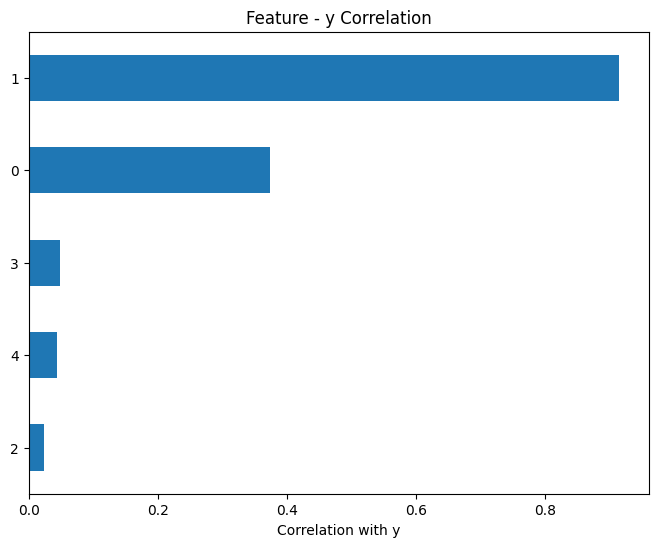

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

y = y.ravel()

X_df = pd.DataFrame(X)

corr = X_df.corrwith(pd.Series(y)).sort_values()

print(corr.sort_values(ascending=False))

corr.plot(kind="barh", figsize=(8, 6), title="Feature - y Correlation")
plt.xlabel("Correlation with y")
plt.show()

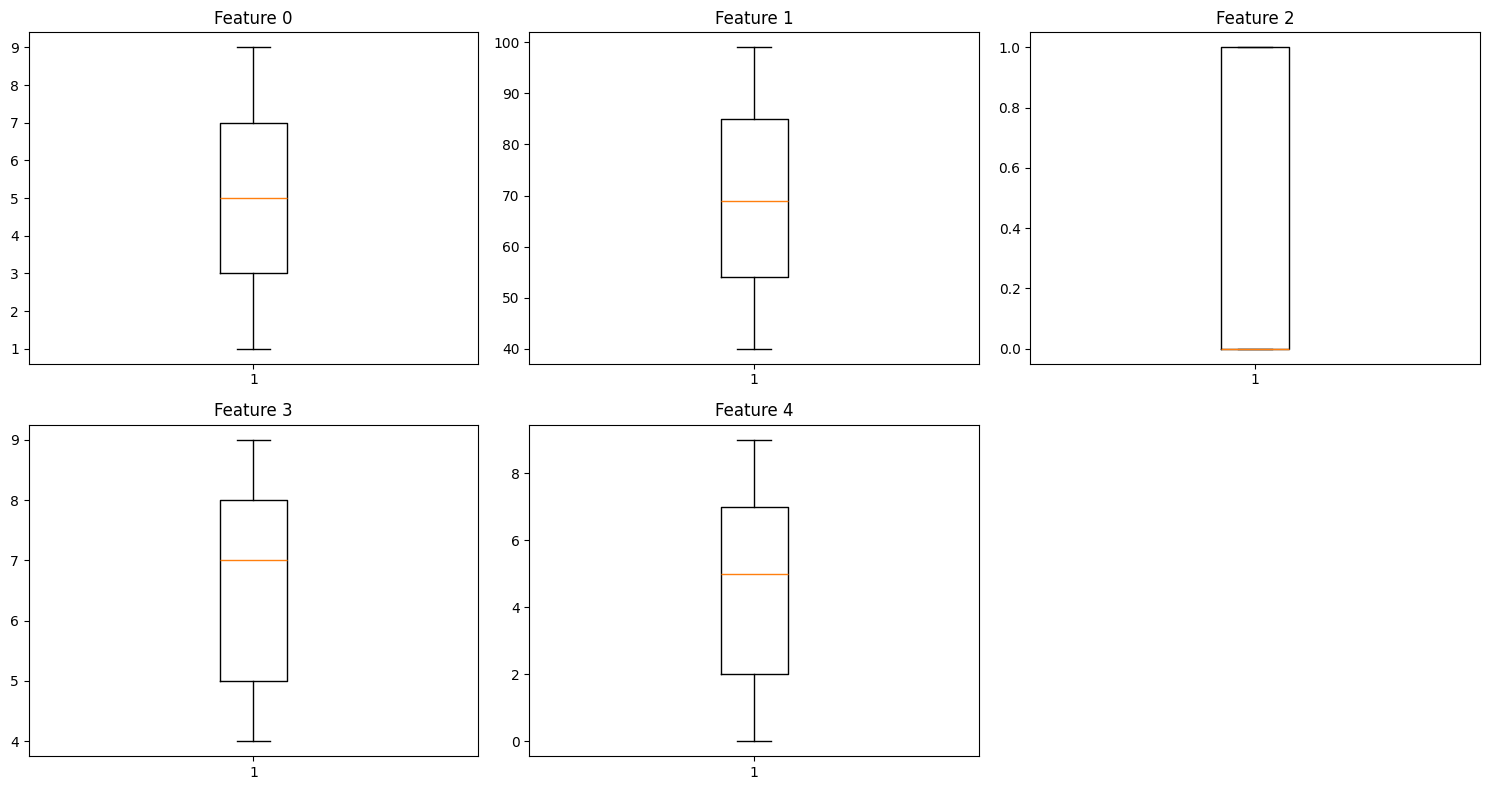

In [7]:
import matplotlib.pyplot as plt
import math

n_cols = 3
n_rows = math.ceil(X.shape[1] / n_cols)

plt.figure(figsize=(15, 4 * n_rows))

for i in range(X.shape[1]):
    plt.subplot(n_rows, n_cols, i + 1)
    plt.boxplot(X[:, i])
    plt.title(f"Feature {i}")

plt.tight_layout()
plt.show()

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [9]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train)

LinearRegression()

In [10]:
y_pred = regressor.predict(X_test)
import pandas as pd

results = pd.DataFrame({
    "Predicted": y_pred,
    "Actual": y_test
})

print(results.round(2))

      Predicted  Actual
0         50.45    53.0
1         53.09    50.0
2         78.25    80.0
3         25.39    24.0
4         67.40    64.0
...         ...     ...
1995      90.70    91.0
1996      41.72    42.0
1997      64.57    66.0
1998      25.90    27.0
1999      18.83    21.0

[2000 rows x 2 columns]
